# 

# *The Discrete Fourier Transform and Simple Filtering*

## *Big Picture*

We have been thinking about data as vectors, and about changing
coordinates to understand structure.

-   In SVD, we chose a basis adapted to the data.

-   In PCA, we interpreted those coordinates in terms of variance.
    Today, we choose a **fixed basis** that is good for signals.

The Discrete Fourier Transform (DFT) is just a change of coordinates.

Filtering becomes simple in those coordinates.

# *Signals as Vectors*

## 

A discrete signal of length $N$ is just a vector

$$
x = (x_0, x_1, \dots, x_{N-1})^T \in \mathbb{C}^N.
$$

We can think of each point $x_n$ as a sample from a presumably
continuous signal.

Examples: for $N=4$, $$
x_1 = [1,2,3,4], \quad x_2 = [1,-1,1,-1].
$$

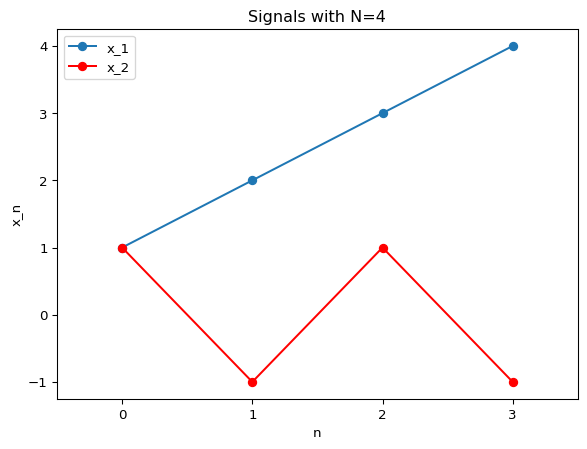

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x_1 = np.array([1,2,3,4])
plt.plot(x_1 , marker='o')
x_2 = np.array([1,-1,1,-1])
plt.plot(x_2, marker='o', color='red')
plt.legend(['x_1', 'x_2'])
plt.xlabel("n")
plt.ylabel("x_n")
plt.xlim(-0.5, 3.5)
plt.xticks([0, 1, 2, 3])
plt.title('Signals with N=4')
plt.show()

## 

Or for $N=10$, $$
x = [1,2,3,4,5,6,7,8,9,10], \quad x = [1,3,1,5,1,7,1,9,1,11].
$$

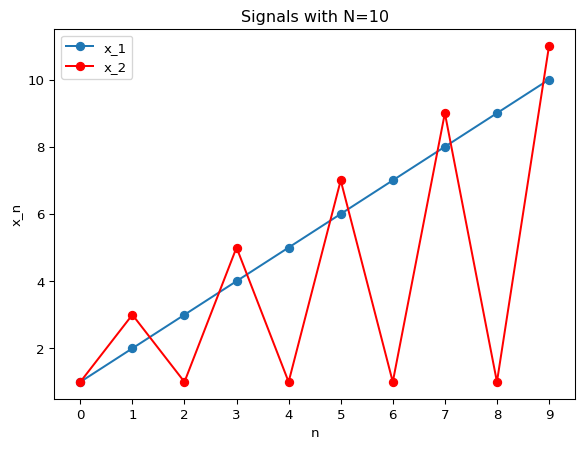

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x_1 = np.array([1,2,3,4,5,6,7,8,9,10])
plt.plot(x_1 , marker='o')
x_2 = np.array([1,3,1,5,1,7,1,9,1,11])
plt.plot(x_2, marker='o', color='red')
plt.legend(['x_1', 'x_2'])
plt.xlabel("n")
plt.ylabel("x_n")
plt.xlim(-0.5, 9.5)
plt.xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
plt.title('Signals with N=10')
plt.show()

# *Discrete Fourier Transform*

## *Fourier series*

The Fourier series of a continuous function $f(t)$ is an expansion into
sines and cosines:

$$
f(t)=a_{0}+a_{1} \cos t+b_{1} \sin t+a_{2} \cos 2 t+b_{2} \sin 2 t+\cdots
$$

. . .

**Euler’s formula** tells us that the complex exponential $e^{i t}$ is a
combination of $\cos t$ and $\sin t$:

$$
e^{i t}=\cos t+i \sin t
$$

. . .

So we can rewrite the Fourier series using complex exponentials:

$$
f(t)=c_{0}+c_{1} e^{i t}+c_{2} e^{2 i t}+\cdots = \sum_k c_k\cdot e^{i k t}
$$

. . .

The coefficients $c_{0}, c_{1}, c_{2}, \ldots$ are related to the $a$’s
and $b$’s.

For example, $c_{1}=a_{1}-i b_{1}$.

## *Discrete signals*

But here we are interested in discrete signals. To connect with the
notation from earlier in the lecture, instead of $f(t)$, we have
$f[n]=x_n$ for $n = 0,1,\dots,N-1$.

. . .

In this case, we have basis vectors

$$
f_k[n] = e^{i 2\pi kn/N}, \quad \text{for } n = 0,1,\dots,N-1.
$$

. . .

These are continuous complex exponentials (cosines and sines), but
sampled at $N$ points.

## 

We will have one basis vector, or Fourier mode, for each frequency index
$k = 0,1,\dots,N-1$.

The frequency index $k$ is the number of times the underlying continuous
oscillation fits into $N$ samples.

These vectors form an orthogonal basis of $\mathbb{C}^N$.

So every signal can be written as a combination of oscillations.

## 

The Fourier basis vector or mode $\mathbf{f}_k$ is given by $$
\mathbf{f}_k = \begin{bmatrix} e^{i 2\pi k \cdot 0/N} \\ e^{i 2\pi k \cdot 1/N} \\ \vdots \\ e^{i 2\pi k \cdot (N-1)/N} \end{bmatrix}.
$$

. . .

Each mode $\mathbf{f}_k$ traces one of the possible discrete
oscillations.

-   $k=0$ → constant signal
-   small $k$ → slow oscillation
-   large $k$ → rapid oscillation
-   $k=N/2$ → fastest oscillation, $N/2$ cycles in $N$ samples
-   $k$ larger than $N/2$ → oscillation actually slower (will describe
    with pictures)

## *Visualizing the Fourier basis vectors*

. . .

Let’s look at these basis vectors for $N=4$:

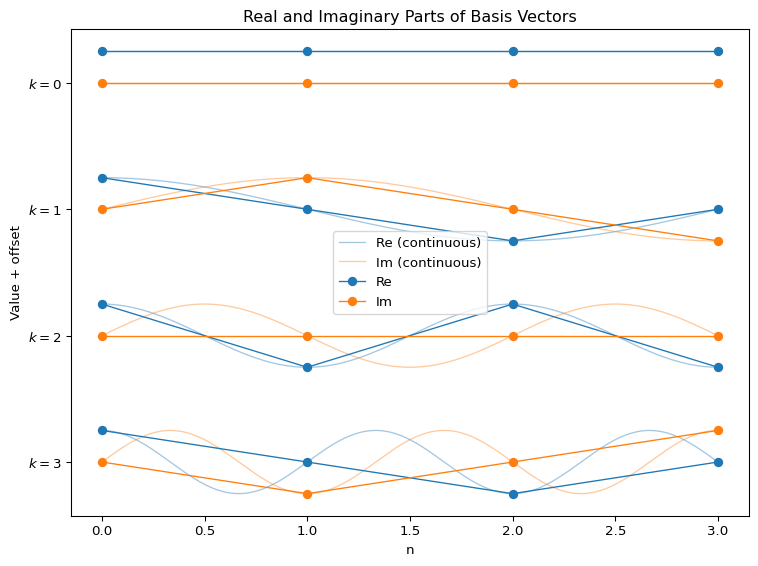

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 4
N_fine = 1000
n_fine = np.linspace(0, N - 1, N_fine)
f_k = np.array([np.exp(2j * np.pi * k * np.arange(N) / N) for k in range(N)])

plt.figure(figsize=(8, 6))
offsets = np.arange(N, 0, -1)*4  # 10, 9, ..., 1

for k in range(N):
    # Continuous curves (as if sampled at N_fine points)
    re_continuous = np.cos(2 * np.pi * k * n_fine / N) + offsets[k]
    im_continuous = np.sin(2 * np.pi * k * n_fine / N) + offsets[k]
    plt.plot(n_fine, re_continuous, color='C0', alpha=0.4, linewidth=1, zorder=0, label='Re (continuous)' if k == 0 else "")
    plt.plot(n_fine, im_continuous, color='C1', alpha=0.4, linewidth=1, zorder=0, label='Im (continuous)' if k == 0 else "")
    # Discrete samples
    y_real = f_k[k].real + offsets[k]
    y_imag = f_k[k].imag + offsets[k]
    plt.plot(np.arange(N), y_real, marker='o', color='C0', linewidth=1, zorder=1, label='Re' if k == 0 else "")
    plt.plot(np.arange(N), y_imag, marker='o', color='C1', linewidth=1, zorder=2, label='Im' if k == 0 else "")
# Set y-ticks to correspond to the offsets so they show k values
plt.yticks(offsets, [f'$k={k}$' for k in range(N)])

plt.xlabel('n')
plt.ylabel('Value + offset')
plt.title('Real and Imaginary Parts of Basis Vectors')
plt.legend()
plt.tight_layout()
plt.show()

## 

The four vectors given by the blue (real) and orange (imaginary) points
form a basis of $\mathbb{C}^4$:

In [5]:
# Calculate and display the explicit values of the DFT basis vectors for N=4 using sympy for nice output
import sympy as sp

N = 4
k_vals = list(range(N))
n_vals = list(range(N))
omega = sp.exp(2 * sp.pi * sp.I / N)  # fundamental N-th root of unity

# Build the matrix of basis vectors: each row k is [omega^(k n) for n=0..N-1]
F = sp.Matrix(N, N, lambda k, n: omega**(k * n))
F

(Each column $k$ of this matrix is $\mathbf{f}_k$, the $k$-th basis
vector.)

. . .

## *For $N$=10*

. . .

Let’s look at these basis vectors for $N=4$:

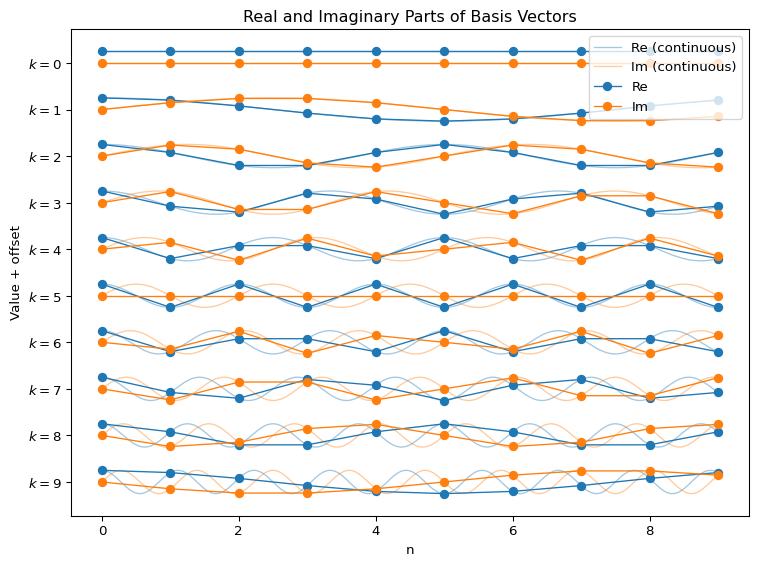

In [6]:
import numpy as np
import matplotlib.pyplot as plt

N = 10
N_fine = 1000
n_fine = np.linspace(0, N - 1, N_fine)
f_k = np.array([np.exp(2j * np.pi * k * np.arange(N) / N) for k in range(N)])

plt.figure(figsize=(8, 6))
offsets = np.arange(N, 0, -1)*4  # 10, 9, ..., 1

for k in range(N):
    # Continuous curves (as if sampled at N_fine points)
    re_continuous = np.cos(2 * np.pi * k * n_fine / N) + offsets[k]
    im_continuous = np.sin(2 * np.pi * k * n_fine / N) + offsets[k]
    plt.plot(n_fine, re_continuous, color='C0', alpha=0.4, linewidth=1, zorder=0, label='Re (continuous)' if k == 0 else "")
    plt.plot(n_fine, im_continuous, color='C1', alpha=0.4, linewidth=1, zorder=0, label='Im (continuous)' if k == 0 else "")
    # Discrete samples
    y_real = f_k[k].real + offsets[k]
    y_imag = f_k[k].imag + offsets[k]
    plt.plot(np.arange(N), y_real, marker='o', color='C0', linewidth=1, zorder=1, label='Re' if k == 0 else "")
    plt.plot(np.arange(N), y_imag, marker='o', color='C1', linewidth=1, zorder=2, label='Im' if k == 0 else "")
# Set y-ticks to correspond to the offsets so they show k values
plt.yticks(offsets, [f'$k={k}$' for k in range(N)])

plt.xlabel('n')
plt.ylabel('Value + offset')
plt.title('Real and Imaginary Parts of Basis Vectors')
plt.legend()
plt.tight_layout()
plt.show()

## *Expressing a signal*

OK, now we are back in familiar territory!

We have a basis of vectors, and we can express any signal as a
combination of these vectors just by finding the projections onto each
of them.

. . .

So if we have a signal $\mathbf{x} = [x_0, x_1, \dots, x_{N-1}]$, we can
find the coefficients (call them $X_k$) by taking the dot product of
$\mathbf{x}$ with $\mathbf{f}_k$:

$$
X_k = \mathbf{x} \cdot \mathbf{f}_k = \sum_{n=0}^{N-1} x_n e^{-i 2\pi kn/N}.
$$

. . .

This is the Discrete Fourier Transform (DFT)!

## *DFT measures frequency content*

The DFT gives the coordinates of $\mathbf{x}$ in an oscillatory basis

Conceptually:

-   $X_k$ measures “how much frequency $k$ is present.”

-   The DFT is just a coordinate change.

## *Inverse DFT*

The inverse DFT reconstructs the signal, given the coefficients $X_k$:

$$
x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{i 2\pi kn/N}.
$$

## *Relationship to the Fourier series*

For continuous functions, we can find the coefficients by integrating:

$$
c_{k}=\int_{0}^{2 \pi} f(t) e^{-i k t} d t
$$

This is equivalent to taking the *projection* of $f(t)$ onto the basis
function $e^{i k t}$.

. . .

Here instead we have

$$
X_k = \mathbf{x} \cdot \mathbf{f}_k = \sum_{n=0}^{N-1} x_n e^{-i 2\pi kn/N}.
$$

. . .

We do summation instead of integration because both our signal and our
basis functions are discrete.

. . .

# *Example: Computing a Small DFT by Hand ($N=4$)*

## *Computing a Small DFT by Hand ($N=4$)*

Let’s find the DFT of the signal $\mathbf{x} = [1,-1,1,-1]$.

. . .

We define a constant just to make the algebra less messy.

When $N=4$, let

$$
W = e^{-i 2\pi/4} = -i.
$$

. . .

So the formula for the DFT becomes

$$
X_k = \sum_{n=0}^{3} x_n W^{kn}.
$$

. . .

Note that the powers of $W$ cycle:

$$
W^0 = 1, \quad W^1 = -i, \quad W^2 = -1, \quad W^3 = i \quad \text{and then we wrap to} \quad W^4 = 1, \quad W^5 = -i, \quad \text{and so on.}
$$

## 

$$
\mathbf{x} = [1,-1,1,-1], \
\quad X_k = \sum_{n=0}^{3} x_n W^{kn}.
$$

$$
W^0 = 1, \quad W^1 = -i, \quad W^2 = -1, \quad W^3 = i.
$$

. . .

So for $X_0$, we have

$$
X_0 = x_0 W^{0\cdot 0} + x_1 W^{0\cdot 1} + x_2 W^{0\cdot 2} + x_3 W^{0\cdot 3} 
$$

$$
= 1 \cdot 1 + (-1) \cdot 1 + 1 \cdot 1 + (-1) \cdot 1 = 0.
$$ . . .

$X_1$:

$$
\begin{aligned}
X_1 &= x_0 W^{1\cdot 0} + x_1 W^{1\cdot 1} + x_2 W^{1\cdot 2} + x_3 W^{1\cdot 3} \\
&= 1 \cdot 1 + (-1) \cdot (-i) + 1 \cdot (-1) + (-1) \cdot i \\
&= 1 + i - 1 - i = 0.
\end{aligned}
$$

Also zero!

## 

$X_2$:

$$
\begin{aligned}
X_2 &= x_0 W^{2\cdot 0} + x_1 W^{2\cdot 1} + x_2 W^{2\cdot 2} + x_3 W^{2\cdot 3} \\
&= 1 \cdot 1 + (-1) \cdot (-1) + 1 \cdot 1 + (-1) \cdot (-1) \\
&= 4.
\end{aligned}
$$

This one is non-zero!

. . .

Finally, for $X_3$:

$$
\begin{aligned}
X_3 &= x_0 W^{3\cdot 0} + x_1 W^{3\cdot 1} + x_2 W^{3\cdot 2} + x_3 W^{3\cdot 3} \\
&= 1 \cdot 1 + (-1) \cdot i + 1 \cdot (-1) + (-1) \cdot (-i) \\
&= 0.
\end{aligned}
$$

Zero again.

Putting these together, we get

$$
X = [0,0,4,0].
$$

## 

$$
x = [1,-1,1,-1], \quad X = [0,0,4,0].
$$

Interpretation:

All the energy is a in the mode $k=2$.

. . .

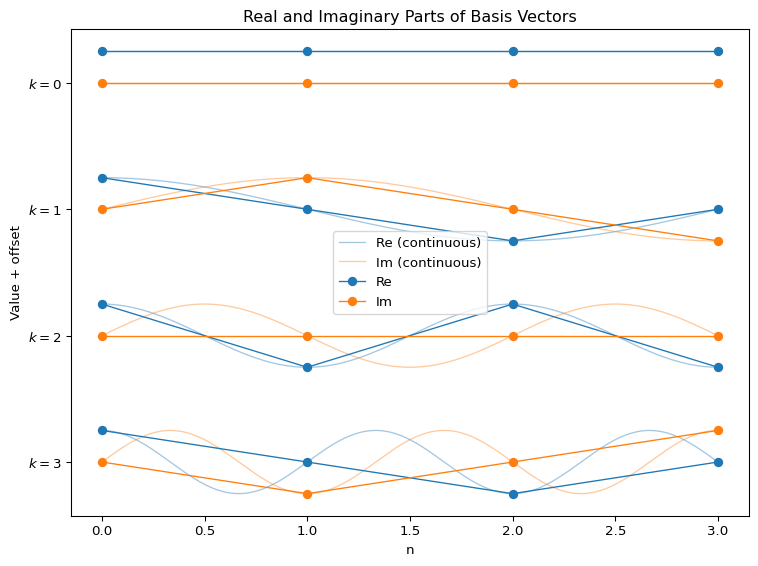

In [7]:
import numpy as np
import matplotlib.pyplot as plt

N = 4
N_fine = 1000
n_fine = np.linspace(0, N - 1, N_fine)
f_k = np.array([np.exp(2j * np.pi * k * np.arange(N) / N) for k in range(N)])

plt.figure(figsize=(8, 6))
offsets = np.arange(N, 0, -1)*4  # 10, 9, ..., 1

for k in range(N):
    # Continuous curves (as if sampled at N_fine points)
    re_continuous = np.cos(2 * np.pi * k * n_fine / N) + offsets[k]
    im_continuous = np.sin(2 * np.pi * k * n_fine / N) + offsets[k]
    plt.plot(n_fine, re_continuous, color='C0', alpha=0.4, linewidth=1, zorder=0, label='Re (continuous)' if k == 0 else "")
    plt.plot(n_fine, im_continuous, color='C1', alpha=0.4, linewidth=1, zorder=0, label='Im (continuous)' if k == 0 else "")
    # Discrete samples
    y_real = f_k[k].real + offsets[k]
    y_imag = f_k[k].imag + offsets[k]
    plt.plot(np.arange(N), y_real, marker='o', color='C0', linewidth=1, zorder=1, label='Re' if k == 0 else "")
    plt.plot(np.arange(N), y_imag, marker='o', color='C1', linewidth=1, zorder=2, label='Im' if k == 0 else "")
# Set y-ticks to correspond to the offsets so they show k values
plt.yticks(offsets, [f'$k={k}$' for k in range(N)])

plt.xlabel('n')
plt.ylabel('Value + offset')
plt.title('Real and Imaginary Parts of Basis Vectors')
plt.legend()
plt.tight_layout()
plt.show()

. . .

This signal alternates every sample point — it is the highest possible
frequency for $N=4$.

# *Filters on Discrete Signals*

## *Filters on Signals*

We’ve seen filters before. They are simply linear transformations that
modify the signal, acting as they slide along the signal.

. . .

For instance, we looked at a filter that took a weighted average of
three adjacent points in the signal. The output point was given by $$
y_n =  \tfrac12(\tfrac12 x_{n-2} + x_{n-1} + \tfrac12 x_{n}).
$$

. . .

(Here we only use points at $n$ and to its left, which is a common
convention in signal processing.)

. . .

## *Filter notation*

$$
y_n =  \tfrac12(\tfrac12 x_{n-2} + x_{n-1} + \tfrac12 x_{n}).
$$

We write this filter as $h = \tfrac12([\tfrac12, 1, \tfrac12])$.

$h$ is a vector of coefficients, describing the effect of the filter at
each point in the sliding window.

. . .

The **transformation** of applying the filter $h$ to a signal
$\mathbf{x}$ is written as $\mathcal{F}_h$:

$$
\mathbf{y} = \mathcal{F}_h(\mathbf{x}).
$$

(This is not a standardized notation, just one I picked for this
lecture.)

## *Example: Simple 2-point filter*

Here, we are going to look at an even simpler filter, which will just
take the average of *two* adjacent points: $x_{n-1}$ and $x_n$.

. . .

$y_n = \tfrac12 (x_{n-1} + x_{n})$

. . .

## *Filtering as matrix multiplication*

If we know the length of the signal, we can write the filter as a matrix
multiplication.

. . .

One small gotcha: we need to decide what to do with the points at the
edges of the signal. Here we will assume that the signal wraps around,
so $x_{-1} = x_5$.

. . .

For our filter $h = \tfrac12([\tfrac12, 1])$, we have

$$
\mathbf{y} = \frac{1}{2} \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 1 \\
1 & 1 & 0 & 0 & 0 & 0 \\
0 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 & 1
\end{bmatrix} \mathbf{x}.
$$

## *Side note: making the filter longer*

$y_n = \tfrac12 (x_{n-1} + x_{n})$

. . .

I am going to write down a longer filter, which has the exact same
effect as this filter. (This is just going to be useful in the next
slide or two!)

. . .

Here it is:

$$
y_n = 0 x_{n-4} + 0 x_{n-3} + 0 x_{n-2} + \tfrac12 x_{n-1} + \tfrac12 x_{n}
$$

. . .

In other words, we have $h = [\tfrac12, \tfrac12, 0, 0, 0]$.

. . .

The only reason I did this is that we are about to work with sums, and
it’s a bit confusing to have a sum of only length 2.

## *A compact way to describe the filter’s action*

$$
y_n = 0 x_{n-4} + 0 x_{n-3} + 0 x_{n-2} + \tfrac12 x_{n-1} + \tfrac12 x_{n}; \quad h = [0, 0, 0, \tfrac12, \tfrac12].
$$

. . .

Rewriting:

$$
y_n = h_5 x_{n-5} + h_4 x_{n-4} + h_3 x_{n-3} + h_2 x_{n-2} + h_1 x_{n-1} + h_0 x_{n}=
\sum_{m=0}^{L-1} h_m x_{n-m}.
$$

. . .

This now is the definition of how a filter acts on a signal:

$$
y_n = \sum_{m=0}^{L-1} h_m x_{n-m}.
$$

## *Filtering as convolution*

$$
y_n = \sum_{m=0}^{L-1} h_m x_{n-m}.
$$

. . .

This is actually a mathematical operation called **convolution**.

. . .

When we take the **convolution** of $\mathbf{x}$ with $\mathbf{h}$, it
is defined as: $$
\mathbf{y} = \mathbf{x} \circledast \mathbf{h} \implies y_n = \sum_{m=0}^{L-1} h_m x_{n-m}.
$$

. . .

This means that the filter transformation is actually a convolution:

$$
\mathcal{F}_h(\mathbf{x}) = \mathbf{x} \circledast \mathbf{h}.
$$

. . .

So we can specify a filter by a vector
$\mathbf{h} = [h_0, h_1, \dots, h_{L-1}]$, and apply it to a signal
$\mathbf{x}$ by convolving them.

## *Summary so far*

**Signals**: - We write a signal $\mathbf{x}$ as a vector of samples:
$\mathbf{x} = [x_0, x_1, \dots, x_{N-1}]$.

-   We can express this signal as a weighted sum of Fourier modes:
    $\mathbf{x} = \sum_{k=0}^{N-1} X_k \mathbf{f}_k$, where each Fourier
    mode is given by $\mathbf{f}_k[n] = e^{i 2\pi k n/N}$.

**Filters**: - We can specify a filter by a vector
$\mathbf{h} = [h_0, h_1, \dots, h_{L-1}]$

-   The filter’s action on a signal $\mathbf{x}$ is given by the formula
    $$
    y_n = \sum_{m=0}^{L-1} h_m x_{n-m}.
    $$

-   More compactly, we can write the filter’s action as a convolution:
    $$
    \mathbf{y} =\mathcal{F}_h(\mathbf{x}) = \mathbf{x} \circledast \mathbf{h}.
    $$

# *Understanding the effects of filters*

## *Understanding the effects of filters*

Can we characterize the effects of a given filter?

. . .

We might start by looking at what the filter does to an example signal.

. . .

A warning: This is not going to be the approach we will end up with!

. . .

Our filter: $h = [\tfrac12, \tfrac12]$

An example signal:

Let’s use a sample signal of length 20:

In [8]:
import numpy as np

pattern = np.array([1, 2, 1, 2, 4])
x = np.tile(pattern, 4)  # Length 20
# add some integer noise
x += np.random.randint(-1, 2, 20)
print(x)

[1 2 1 3 5 0 1 1 3 4 1 1 2 3 3 2 3 0 3 5]

##

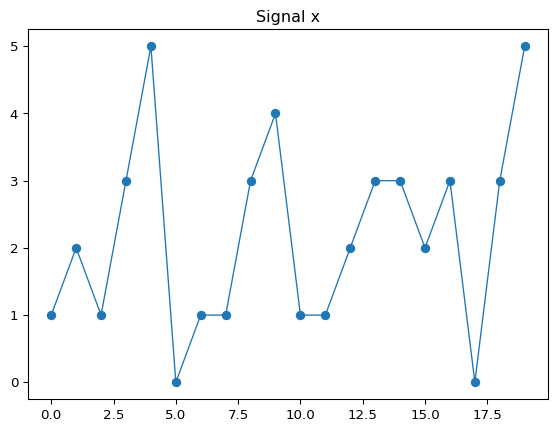

In [9]:
import numpy as np
import matplotlib.pyplot as plt

x = x.astype(int)
N=len(x)
# Plot all points in default color
plt.plot(np.arange(N), x, marker='o', color='C0', linewidth=1, zorder=1)

# Highlight the m
plt.title('Signal x')
plt.show()

## 

Then we apply the filter $h = [\tfrac12, \tfrac12]$.

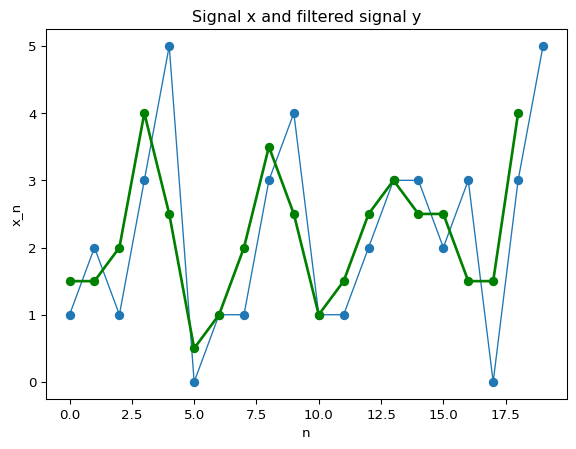

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# x is the original signal

# y is the signal filtered by h = 1/2, 1/2

# Compute the filtered signal y by averaging adjacent pairs (length N-1)
h = np.array([0.5, 0.5])
y = np.convolve(x, h, mode='valid')


# Plot all points in default color
plt.plot(x, marker='o', color='C0', linewidth=1, zorder=1)
plt.plot(y, marker='o', color='green', linewidth=2, zorder=2)
# Highlight the middle 4 points (indices 4-7) in red


plt.xlabel("n")
plt.ylabel("x_n")
plt.title('Signal x and filtered signal y')
plt.show()

$$
y_n = \sum_{m=0}^{1} h_m x_{n-m} = \tfrac12 x_{n-1} + \tfrac12 x_{n}
$$

## 

Hmm. It’s actually kind of hard to see what the filter is doing to this
signal. . . .

But can we be more systematic about this?

## *Finding a special basis for signals*

We understood the actions of matrix multiplication by finding vectors
which behaved simply under the multiplication.

. . .

$$
A \mathbf{v} = \lambda \mathbf{v}
$$

. . .

These were, of course, the eigenvectors of $A$.

. . .

Then if made a basis out of those eigenvectors, we could understand the
action of $A$ on *any* vector $\mathbf{x}$ by expressing $\mathbf{x}$ in
this basis.

. . .

Can we find something equivalent for signals and filters? That is, will
there be a basis of *signals* where the action of a filter is made
simple?

. . .

The answer is yes! And the basis we want will be none other than the DFT
basis.

## *What Does a Filter Do to a Fourier Mode?*

Let us take as our $\mathbf{x}$ one of the Fourier modes, basis vectors
of the DFT, $f_k[n]=e^{i 2\pi kn/N}$.

. . .

For simplicity, define $\zeta_k = 2\pi k/N$. Then

$$
f_k[n] = e^{i \zeta_k n}.
$$

. . .

What happens when we apply the filter $h = [\tfrac12, \tfrac12]$ to this
signal?

## 

We use convolution to see what happens when we apply the filter to the
$k$-th Fourier mode:

$$
\mathbf{y}_k = \mathcal{F}_h(f_k) = f_k \circledast h.
$$

$$
y_k[n] = \sum_{m=0}^{L-1} h_m f_k[n-m]= \sum_{m=0}^{L-1} h_m e^{i \zeta_k (n-m)} = \left( \sum_{m=0}^{L-1} h_m e^{-i \zeta_k m} \right) e^{i \zeta_k n}.
$$

## *Simplifying the expression*

$$
y_k[n] = \sum_{m=0}^{L-1} h_m f_k[n-m]= \sum_{m=0}^{L-1} h_m e^{i \zeta_k (n-m)} = \left( \sum_{m=0}^{L-1} h_m e^{-i \zeta_k m} \right) e^{i \zeta_k n}.
$$

. . .

But wait. This simplifies!

The part inside the parentheses is just a constant, and it doesn’t
depend at all on $n$. Let’s just give it a name, $H(\zeta_k)$.

. . .

$$
H(\zeta_k) \equiv \sum_{m=0}^{L-1} h_m e^{-i \zeta_k m}.
$$

So

$$
y_k[n] = H(\zeta_k) f_k[n].
$$

## 

This holds at every point $n$, so we can write it in vector form as

$$
\mathbf{y}_k = H(\zeta_k) \mathbf{f}_k.
$$

. . .

This means that if our input is one of the Fourier modes, the output is
simply the input scaled by $H(\zeta_k)$.

. . .

**The Fourier modes are the eigenvectors of the filter!**

## *Fourier modes as eigenvectors*

$$
\mathbf{y}_k = H(\zeta_k) \mathbf{f}_k; \quad H(\zeta_k) = \sum_{m=0}^{L-1} h_m e^{-i \zeta_k m} \quad \text{for} \quad k = 0,1,\dots,N-1.
$$

. . .

This derivation didn’t depend on the form of the filter $h$.

. . .

That means that the Fourier modes are the eigenvectors of *every* filter
that we can write as a convolution!

## *Behavior on any signal*

We can now use the DFT to understand the behavior of a filter on any
signal.

. . .

Remember, if we have a signal $\mathbf{x}$, we can write it as a
weighted sum of the DFT basis vectors:

$$
\mathbf{x} = \frac{1}{N} \sum_{k=0}^{N-1} X_k \mathbf{f}_k.
$$

. . .

Since our filter is linear, we can apply it to each of the terms in this
sum separately:

$$
\mathcal{F}_h(\mathbf{x}) = \mathcal{F}_h\left( \frac{1}{N} \sum_{k=0}^{N-1} X_k \mathbf{f}_k \right) = \frac{1}{N} \sum_{k=0}^{N-1}  \mathcal{F}_h(X_k\mathbf{f}_k)
$$

. . .

## 

$$
\mathcal{F}_h(\mathbf{x}) = \frac{1}{N} \sum_{k=0}^{N-1}  \mathcal{F}_h(X_k\mathbf{f}_k)
$$

Since $X_k$ is a constant, we can factor it out of the transformation:

$$
= \frac{1}{N} \sum_{k=0}^{N-1}  X_k \mathcal{F}_h(\mathbf{f}_k)
$$

. . .

Now we can use the fact that the Fourier modes are the eigenvectors of
the filter, so $\mathcal{F}_h(\mathbf{f}_k) = H(\zeta_k) \mathbf{f}_k$,
to write:

$$
\mathcal{F}_h(\mathbf{x}) = \frac{1}{N} \sum_{k=0}^{N-1} X_k H(\zeta_k) \mathbf{f}_k = \frac{1}{N} \sum_{k=0}^{N-1} H(\zeta_k) X_k  \mathbf{f}_k
$$

. . .

So we can describe the action of the filter: it takes each Fourier mode
$k$ and scales it by $H(\zeta_k)$.

## 

$$
\mathcal{F}_h(\mathbf{x}) = \frac{1}{N} \sum_{k=0}^{N-1} X_k H(\zeta_k) \mathbf{f}_k = \frac{1}{N} \sum_{k=0}^{N-1} H(\zeta_k) X_k  \mathbf{f}_k
$$

Steps to understanding what a filter does to a signal of length $N$:

1.  Find the DFT of the signal. This will decompose the signal into a
    weighted sum of $N$ Fourier modes $\mathbf{f}_k$, with weights
    $X_k$.
2.  For each $k$, compute $H(\zeta_k)$ for the filter $h$.
3.  Multiply each Fourier mode $\mathbf{f}_k$ by $X_k$ and $H(\zeta_k)$
    and sum the results to get the output.

. . .

Interpretation:

-   The filter scales each Fourier mode by a complex number.

. . .

What does it mean to scale a mode by a complex number? We will look at
an example to understand.

# *Analyzing two simple filters*

## *Lowpass: Moving Average*

$$
h = \left[\tfrac12, \tfrac12\right].
$$

Then we calculate the frequency response using the formula we derived:

$$
H(\zeta) = \sum_{m=0}^{L-1} h_m e^{-i \zeta m} = \tfrac12(e^0 + e^{-i\zeta})=\tfrac12(1 + e^{-i\zeta}).
$$

## *Interlude: Complex Exponentials*

Our frequency response is:

$$
H(\zeta) =\tfrac12(1 + e^{-i\zeta}).
$$

. . .

Let’s pause here. We will get something like this for every filter we
analyze – something that’s a sum of complex exponentials.

. . .

Complex exponentials are vectors in the complex plane, and they have
**magnitude** and **angles** (or **phases**).

. . .

For our purposes here, we want to be able to find the magnitudes. And in
general this is a bit complicated!

. . .

Sometimes, there are simple trigenometric identities that can help. We
will use one on the next slide.

. . .

But often, we only end up wanting to know the magnitude for certain
values of $\zeta$ like $0$ and $\pi$ – and this turns out to simplify
things even more!

## 

$$
H(\zeta) =\tfrac12(1 + e^{-i\zeta}).
$$

We factor out $e^{-i\zeta/2}$:

$$
H(\zeta) =
\tfrac12
e^{-i\zeta/2}
\left(
e^{i\zeta/2} + e^{-i\zeta/2}
\right).
$$

## 

$$
H(\zeta) =
\tfrac12
e^{-i\zeta/2}
\left(
e^{i\zeta/2} + e^{-i\zeta/2}
\right).
$$

. . .

Recall Euler’s identity:

$$
e^{i\theta} + e^{-i\theta} = 2\cos(\theta).
$$

. . .

Apply this with $\theta = \zeta/2$:

$$
e^{i\zeta/2} + e^{-i\zeta/2}
= 2\cos(\zeta/2).
$$

. . .

So

$$
H(\zeta) =
\tfrac12
e^{-i\zeta/2}
\left(
2\cos(\zeta/2)
\right)=e^{-i\zeta/2}\cos(\zeta/2).
$$

## *Finding the Magnitude*

$$
H(\zeta) =
e^{-i\zeta/2}
\cos(\zeta/2).
$$

Now we clearly see two pieces:

-   A **phase**, which is a complex number of magnitude 1:
    $e^{-i\zeta/2}$

(Every single complex exponential of the form $e^{i\theta}$ has
magnitude 1. *Sums* of complex exponentials don’t necessarily have
magnitude 1, though!)

-   A scaling factor or **gain**, which is a real number:
    $\cos(\zeta/2)$

. . .

Notice that the gain is just the magnitude of the complex number
$H(\zeta)$:

$$
|H(\zeta)| = \cos(\zeta/2).
$$

## *Writing the frequency response in terms of $k$*

. . .

Remembering our definition of $\zeta_k = 2\pi k/N$, we have

**Phase shift**: $e^{-i\zeta_k/2}=e^{-i \pi k/N}$.

**Gain**: $\cos(\zeta_k/2)=\cos(\pi k/N)$.

. . .

The action of the filter on a Fourier mode $k$ is to *shift* the phase
by $e^{-i\pi k/N}$ and to *scale* the amplitude by $\cos(\pi k/N)$.

## *Checking the Endpoints*

$$
|H(\zeta_k)| = |\cos(\pi k/N)|.
$$

Let’s understand what the filter does at the lowest possible frequency
and at the highest possible frequency.

. . .

At the *lowest* frequency, $k=0$:

$$
|H(0)| = |\cos(0)| = 1.
$$

. . .

At the highest frequency (e.g. $k = N/2$ when $N$ is even),
$\zeta = \pi$:

$$
|H(\pi)| = |\cos(\pi/2)| = 0.
$$

So:

-   Slow oscillations (small $k$) pass through.

-   Rapid oscillations (near $k=N/2$) are suppressed.

That’s exactly what a lowpass filter does.

## *Highpass: Difference Filter*

Let’s go through the same process for a highpass filter.

$$
h = \left[-\tfrac12, \tfrac12\right].
$$

. . .

Then $$
H(\zeta) = -\tfrac12 + \tfrac12 e^{-i\zeta}.
$$

. . .

Rewrite:

$$
H(\zeta) = e^{-i\zeta/2}(-i \sin(\zeta/2)).
$$

. . .

Find the magnitude of the frequency response:

$$
|H(\zeta)| = |\sin(\zeta/2)|.
$$

## 

$$
|H(\zeta)| = |\sin(\zeta/2)|.
$$

Check high and low frequencies:

$$
|H(0)| = 0, \qquad |H(\pi)| = 1.
$$

Low frequencies are suppressed. Rapid changes are emphasized.

This is a highpass filter.

## *Final Conceptual Summary*

The DFT is just a coordinate change:

-   Time domain → frequency domain.

-   Convolution → multiplication.

-   Filtering → scaling oscillations.

For the homework, you only need:

$$
X_k = \sum_{n=0}^{N-1} x_n e^{-i 2\pi kn/N},
$$

$$
H(\zeta) = \sum_{m=0}^{L-1} h_m e^{-i \zeta m},
$$

and the idea that filters act differently on different frequencies.

Everything else is interpretation.